<a href="https://colab.research.google.com/github/Likelipop/algorithm-analysis/blob/main/Lab08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BTTH TUẦN 8
--
Tên: Trần Tiến Đạt

MSSV: 22110039

# Bài 1

## ĐỀ BÀI

Ta xây dựng một dãy các từ Fibonacci như sau:

- `f0 = "abc"`
- `f1 = "def"`
- `f(n+1) = strcat(fn, f(n-1)), với n ≥ 1`

Trong đó, hàm `strcat` là hàm nối hai chuỗi thành một chuỗi mới.

Ví dụ:

```text
strcat("abc", "def") = "abcdef"

## TRIỂN KHAI

### 2.1 Nhận xét

Theo định nghĩa:

```text
fn = f(n-1) + f(n-2)
```

Do đó:

* Phần đầu của `fn` chính là `f(n-1)`
* Phần sau của `fn` chính là `f(n-2)`

Độ dài của chuỗi cũng thỏa:

```text
len(fn) = len(f(n-1)) + len(f(n-2))
```

Vì vậy, để tìm ký tự thứ `k` trong `fn`, ta chỉ cần xác định:

* `k` nằm trong phần `f(n-1)` hay
* nằm trong phần `f(n-2)`

---

## 3. Tiền xử lý độ dài các chuỗi

Thuật toán không tạo trực tiếp các chuỗi Fibonacci vì kích thước tăng rất nhanh.

Thay vào đó, ta chỉ lưu:

```python
length[i] = độ dài của fi
```

với công thức:

```python
length[i] = length[i - 1] + length[i - 2]
```

Điều này giúp xác định nhanh vị trí của ký tự cần tìm.

---

## 4. Chi tiết thuật toán truy hồi

Giả sử cần tìm ký tự thứ `k` trong `fn`.

### Trường hợp cơ sở

* Nếu `n == 0` → trả về `f0[k]`
* Nếu `n == 1` → trả về `f1[k]`

---

### Trường hợp truy hồi

Do:

```text
fn = f(n-1) + f(n-2)
```

nên:

* Nếu `k < length[n-1]`

  → ký tự cần tìm nằm trong `f(n-1)`

  → gọi đệ quy:

```python
get_char(n - 1, k)
```

* Ngược lại

  → ký tự nằm trong `f(n-2)`

  → bỏ qua phần `f(n-1)` nên cập nhật vị trí:

```python
k = k - length[n-1]
```

→ gọi:

```python
get_char(n - 2, k - length[n - 1])
```


In [1]:
import time
import matplotlib.pyplot as plt
import seaborn as sns

f0 = "abc"
f1 = "def"

# =========================
# Tính độ dài các chuỗi Fibonacci
# =========================

MAX_N = 100

length = [0] * (MAX_N + 1)

length[0] = len(f0)
length[1] = len(f1)

for i in range(2, MAX_N + 1):
    length[i] = length[i - 1] + length[i - 2]


# =========================
# Hàm tìm ký tự thứ k của f(n)
# =========================

def get_char(n, k):
    """
    Hàm giải quyết bài toán trên ( lấy ký tự thứ k của f_n )
    """

    # Kiểm tra hợp lệ
    if k < 0 or k >= length[n]:
        return "Index out of range"

    # Base cases
    if n == 0:
        return f0[k]

    if n == 1:
        return f1[k]

    # Recursive cases
    if k < length[n - 1]:
        return get_char(n - 1, k)
    else:
        return get_char(n - 2, k - length[n - 1])



## Test

In [2]:
n = 2
k = 5

print("Độ dài f(", n, ") =", length[n])
print("Ký tự thứ", k, "của f(", n, ") là:", get_char(n, k))

Độ dài f( 2 ) = 6
Ký tự thứ 5 của f( 2 ) là: c


# ĐỘ PHỨC TẠP

## Cố định k, chạy n

n =  8 | avg_time = 0.0000009676 s
n =  9 | avg_time = 0.0000012798 s
n = 10 | avg_time = 0.0000011440 s
n = 11 | avg_time = 0.0000012628 s
n = 12 | avg_time = 0.0000015290 s
n = 13 | avg_time = 0.0000016382 s
n = 14 | avg_time = 0.0000017096 s
n = 15 | avg_time = 0.0000017531 s
n = 16 | avg_time = 0.0000018929 s
n = 17 | avg_time = 0.0000020980 s
n = 18 | avg_time = 0.0000021348 s
n = 19 | avg_time = 0.0000022954 s
n = 20 | avg_time = 0.0000024420 s
n = 21 | avg_time = 0.0000026511 s
n = 22 | avg_time = 0.0000026409 s
n = 23 | avg_time = 0.0000027171 s
n = 24 | avg_time = 0.0000028592 s
n = 25 | avg_time = 0.0000029987 s
n = 26 | avg_time = 0.0000031082 s
n = 27 | avg_time = 0.0000038492 s
n = 28 | avg_time = 0.0000034190 s
n = 29 | avg_time = 0.0000040180 s
n = 30 | avg_time = 0.0000035564 s
n = 31 | avg_time = 0.0000036539 s
n = 32 | avg_time = 0.0000040803 s
n = 33 | avg_time = 0.0000039148 s
n = 34 | avg_time = 0.0000044870 s
n = 35 | avg_time = 0.0000041694 s
n = 36 | avg_time = 

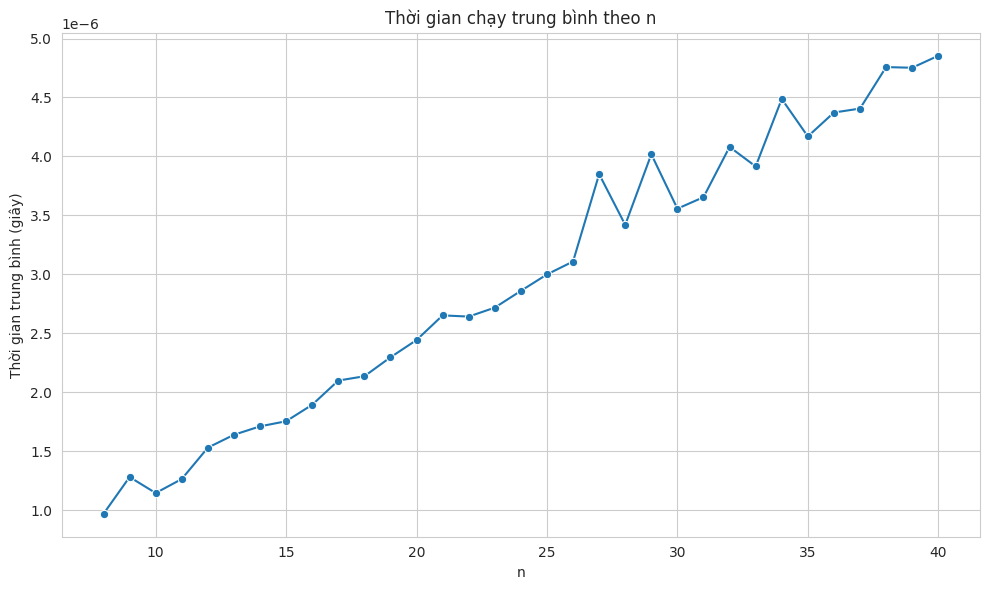

In [21]:
MAX_N = 40

k = 100

NUM_TRIALS = 100

n_values = []
time_values = []

for n in range(2, MAX_N + 1):

    if k >= length[n]:
        continue

    total_time = 0

    for _ in range(NUM_TRIALS):

        start = time.perf_counter()

        get_char(n, k)

        end = time.perf_counter()

        total_time += (end - start)

    avg_time = total_time / NUM_TRIALS

    n_values.append(n)
    time_values.append(avg_time)

    print(f"n = {n:2d} | avg_time = {avg_time:.10f} s")


# =========================
# Vẽ biểu đồ
# =========================

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.lineplot(
    x=n_values,
    y=time_values,
    marker="o"
)

plt.title("Thời gian chạy trung bình theo n")
plt.xlabel("n")
plt.ylabel("Thời gian trung bình (giây)")

plt.tight_layout()
plt.show()

## Cố định n, chạy k

range(0, 364179)
k =      0 | avg_time = 0.0000078760 s
k =   5000 | avg_time = 0.0000030409 s
k =  10000 | avg_time = 0.0000034413 s
k =  15000 | avg_time = 0.0000027928 s
k =  20000 | avg_time = 0.0000026774 s
k =  25000 | avg_time = 0.0000028203 s
k =  30000 | avg_time = 0.0000028569 s
k =  35000 | avg_time = 0.0000029810 s
k =  40000 | avg_time = 0.0000028312 s
k =  45000 | avg_time = 0.0000028011 s
k =  50000 | avg_time = 0.0000025535 s
k =  55000 | avg_time = 0.0000029887 s
k =  60000 | avg_time = 0.0000028344 s
k =  65000 | avg_time = 0.0000029179 s
k =  70000 | avg_time = 0.0000028959 s
k =  75000 | avg_time = 0.0000029198 s
k =  80000 | avg_time = 0.0000051712 s
k =  85000 | avg_time = 0.0000027175 s
k =  90000 | avg_time = 0.0000029217 s
k =  95000 | avg_time = 0.0000030061 s
k = 100000 | avg_time = 0.0000027712 s
k = 105000 | avg_time = 0.0000026471 s
k = 110000 | avg_time = 0.0000027659 s
k = 115000 | avg_time = 0.0000034918 s
k = 120000 | avg_time = 0.0000027030 s
k = 1250

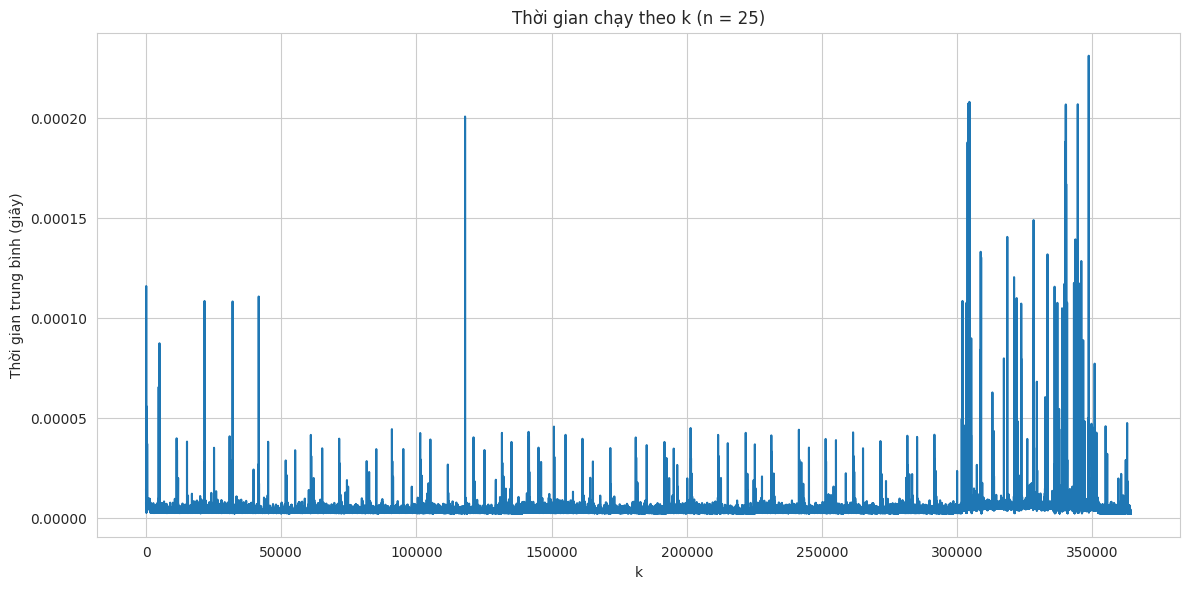

In [25]:
FIXED_N = 25

NUM_TRIALS = 10

k_values = []
time_values = []

print(range(length[FIXED_N]))
for k in range(length[FIXED_N]):

    total_time = 0

    for _ in range(NUM_TRIALS):

        start = time.perf_counter()

        get_char(FIXED_N, k)

        end = time.perf_counter()

        total_time += (end - start)

    avg_time = total_time / NUM_TRIALS

    k_values.append(k)
    time_values.append(avg_time)

    if k % 5000 == 0:
        print(f"k = {k:6d} | avg_time = {avg_time:.10f} s")


# =========================
# Vẽ biểu đồ
# =========================

sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=k_values,
    y=time_values
)

plt.title(f"Thời gian chạy theo k (n = {FIXED_N})")
plt.xlabel("k")
plt.ylabel("Thời gian trung bình (giây)")

plt.tight_layout()
plt.show()

# Phân tích độ phức tạp của thuật toán

Xét thuật toán `get_char(n, k)` dùng để tìm ký tự thứ `k` của từ Fibonacci `f_n`.

Ta có định nghĩa:

```text id="tpzjlwm"
f_n = f_{n-1} + f_{n-2}
```


Thuật toán hoạt động như sau:

* Nếu:

```text id="ql1v4v"
k < |f_{n-1}|
```

thì ký tự cần tìm nằm trong `f_{n-1}`.

* Ngược lại, ký tự nằm trong `f_{n-2}` với chỉ số mới:

```text id="m0nlx6"
k' = k - |f_{n-1}|
```

Do đó, tại mỗi bước thuật toán chỉ thực hiện đúng **một** lời gọi đệ quy.

---

# 1. Độ phức tạp thời gian

## Định nghĩa

Gọi:

```text id="eznng5"
T(n)
```

là thời gian thực hiện của hàm `get_char(n, k)`.

---

## Thiết lập hệ thức truy hồi

Trong mỗi lời gọi hàm:

* thực hiện một số hữu hạn phép toán cơ bản:

  * so sánh,
  * phép gán,
  * phép truy cập mảng,

nên chi phí là:

```text id="1t06o3"
\Theta(1)
```

Sau đó thuật toán gọi đệ quy:

```text id="pr2r97"
get_char(n-1, k)
```

hoặc:

```text id="u6r9g3"
get_char(n-2, k')
```

Do đó:

```text id="5uz0jj"
T(n) =
\begin{cases}
T(n-1) + \Theta(1) \\
\text{hoặc} \\
T(n-2) + \Theta(1)
\end{cases}
```

Trong trường hợp xấu nhất:

```text id="fdhl7j"
T(n) \le T(n-1) + c
```

với `c > 0` là hằng số.

---

## Giải hệ thức truy hồi

Khai triển truy hồi:

```text id="1p80yn"
\begin{aligned}
T(n)
&\le T(n-1) + c \\
&\le T(n-2) + 2c \\
&\le T(n-3) + 3c \\
&\;\;\vdots \\
&\le T(1) + (n-1)c
\end{aligned}
```

Vì:

```text id="7m5nzu"
T(1) = \Theta(1)
```

nên tồn tại các hằng số `a, b > 0` sao cho:

```text id="v0st2w"
T(n) \le an + b
```

Suy ra:

```text id="7z91s1"
T(n) = O(n)
```

Mặt khác, trong trường hợp xấu nhất thuật toán phải đi qua gần như toàn bộ chiều sâu đệ quy, nên:

```text id="8nrjku"
T(n) = \Omega(n)
```

Do đó:

```text id="ftwl3f"
T(n) = \Theta(n)
```

---

# 2. Độ phức tạp bộ nhớ

Thuật toán sử dụng hai thành phần bộ nhớ chính.

---

## 2.1 Mảng lưu độ dài

Mảng:

```python id="tb57iw"
length[0...n]
```

lưu độ dài của các từ Fibonacci.

Số phần tử là:

```text id="sh74ew"
n + 1
```

Do đó bộ nhớ cần dùng là:

```text id="b7g5bo"
\Theta(n)
```

---

## 2.2 Ngăn xếp đệ quy

Mỗi lời gọi đệ quy làm giảm chỉ số:

```text id="2d6nmy"
n \to n-1
```

hoặc:

```text id="v7od6z"
n \to n-2
```

Vì vậy chiều sâu đệ quy tối đa là:

```text id="wy0i4g"
n
```

Mỗi mức đệ quy chỉ dùng lượng bộ nhớ hằng số, nên tổng bộ nhớ stack là:

```text id="x3vr69"
\Theta(n)
```

---

# 3. Kết luận

## Độ phức tạp thời gian

```text id="wj0e14"
\boxed{T(n) = \Theta(n)}
```

---

## Độ phức tạp bộ nhớ

```text id="mlz03l"
\boxed{S(n) = \Theta(n)}
```

trong đó:

* `Θ(n)` cho mảng `length`,
* `Θ(n)` cho stack đệ quy.

---

# 4. Nhận xét

Thuật toán hiệu quả hơn rất nhiều so với việc xây dựng trực tiếp chuỗi Fibonacci.

Nếu xây dựng toàn bộ chuỗi:

```text id="y4y9w5"
|f_n| \approx \varphi^n
```

(với `\varphi` là tỉ lệ vàng), nên thời gian và bộ nhớ sẽ tăng theo cấp số mũ.

Trong khi đó, thuật toán trên chỉ cần:

```text id="rpr1n9"
\Theta(n)
```

nên có hiệu quả vượt trội đối với `n` lớn.
